# **LAB Speech Recognition - Session 3**
### **MFFC Part 1**

MFCC (Mel Frequency Cepstral Coefficients) = Metode mengekstrak fitur-fitur dari audio

MFCC akan menggunakan MEL Scale untuk membagi pita frekuensi menjadi pita-pita yang lebih kecil, lalu mengekstrak Cepstral Coefficients dari setiap pita frekuensi tersebut. Hasil ekstraksi ini akan digunakan sebagai fitur untuk pengenalan suara.

C2 (65Hz) -> C4 (262Hz)
G6 (1568Hz) A6 (1760Hz)

Mel Scale = skala yang didasarkan oleh manusia membedakan frekuensi.

Cepstral Coefficient  = Kumpulan fitur-fitur yang umum digunakan untuk speech processing dan recognition.

Coefficient tersebut dilkalkulasikan menggunakan cepstrum

In [1]:
# import library 
import os
import numpy as np
import scipy
from scipy.io import wavfile
import scipy.fftpack as fft # buat FFT
from scipy.signal import get_window # Window Function
from IPython.display import Audio, display
import matplotlib.pyplot as plt

In [2]:
SAMPLE_AUDIO_PATH = "sesi3-files/audio.wav"
display(Audio(SAMPLE_AUDIO_PATH, rate=16000))

# **Load Audio**

In [3]:
# Load Audio
sample_rate, audio = wavfile.read(SAMPLE_AUDIO_PATH)
audio_duration = len(audio) / sample_rate # untuk tahu durasi audio dalam detik

print(f"Sample Rate: {sample_rate} Hz")
print(f"Audio Duration: {audio_duration:.2f} seconds")

Sample Rate: 44100 Hz
Audio Duration: 18.86 seconds


# **1. Normalization** 
Untuk mengatur level audio agar amplitudonya ada di rang -1 sampai 1

Agar sinyal audion memiliki volume yang konsisten di seluruh rekaman audio

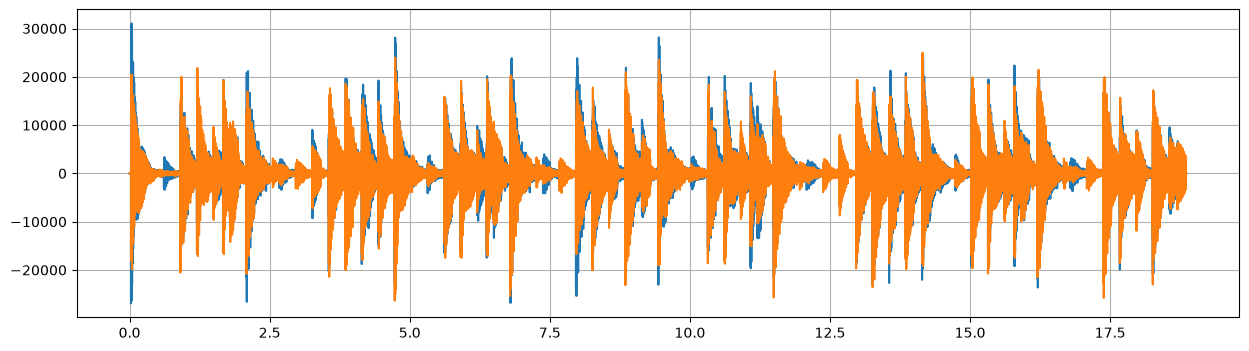

In [ ]:
# Sebelum Normalization (dari -20000 sampai 30000)
plt.figure(figsize=(15, 4))
plt.plot(np.linspace(0, audio_duration, num=len(audio)), audio)
plt.grid(True)

In [5]:
# 1. Normalization

audio = audio / np.max(np.abs(audio))  # Normalize audio to [-1, 1]

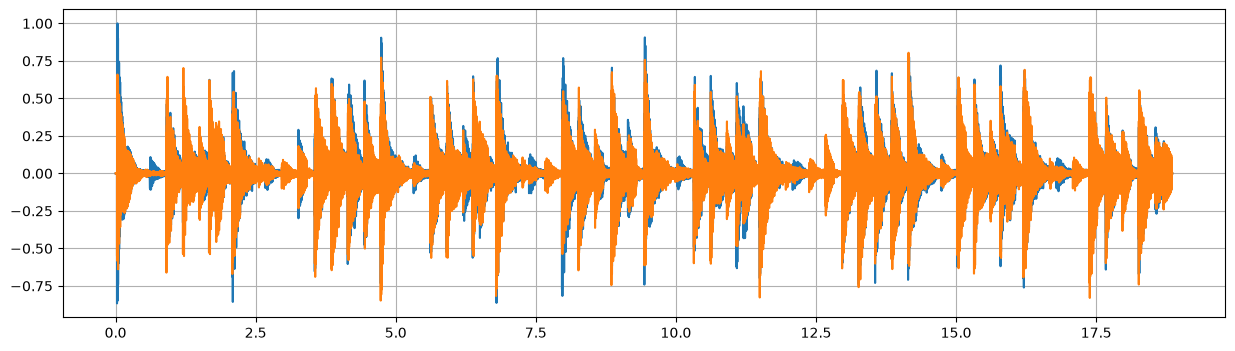

In [6]:
# Setelah Normalization
plt.figure(figsize=(15, 4))
plt.plot(np.linspace(0, audio_duration, num=len(audio)), audio)
plt.grid(True)

# Frame Blocking
Proses membag sinyal audio menjadi beberapa segmen-segmen yang lebih kecil (frame) dengan durasi tertentu.

In [ ]:
# Frame Blocking
# memecah audio menjadi segmen2 kecil yang overlap
# Proses membag sinyal audio menjadi beberapa segmen-segmen yang lebih kecil (frame) dengan durasi tertentu.

def frame_audio(audio, FFT_size, hop_size, sample_rate):
    # Audio: Signal size kita
    # FFT_size: jumlah sample dalam 1 frame
    # hop_size: jarak antar frame dalam ms (miliseconds)
    # sample_rate: sample rate dari audio
    
    # Padding: nambah di awal dan akhir audio supaya framingnya pas / agar bagian awal/akhir audio tidak langsung dianggap sebagai 0
    # [1,2,3,4,5] -> [3,2,1,2,3,4,5,4,3] (contoh)
    audio = np.pad(audio, int(FFT_size/2), mode='reflect')
    
    # ubah dari hop_size menjadi hop_length
    # menghitung berapa sample jarak antar frame 1 dengan frame berikutnya
    frame_len = np.round(sample_rate * (hop_size / 1000)).astype(int)
    
    # menghitunug berapa banyak frame yang terbentuk dari audio
    frame_num = int((len(audio) - FFT_size) / frame_len) + 1
    
    # Inisialisasi matriks kosong untuk simpan hasil frame blocking (framing)
    frames = np.zeros((frame_num, FFT_size))
    
    # Looping untuk isi matriks frame
    # Tiap iterasi, ambil potongan audio sebesar FFT_size
    for i in range(frame_num):
        frames[i] = audio[i * frame_len : i * frame_len + FFT_size]
        
    return frames

# Gambarannya, biar dia overlapping

# Frame 1
# [-------------] 2048

# Frame 2
#       [-------------] 2048

In [ ]:
hop_size = 15  # in milliseconds
FFT_size = 2048  # in samples
audio_framed = frame_audio(audio, FFT_size, hop_size, sample_rate)

audio_framed.shape  # (frame_num, FFT_size)

In [ ]:
# Windowing: membuat ujung awal dan akhir dekat / sampai 0
# Tujuannya mengurangi spectral leakage saat FFT

window = get_window('hann', FFT_size, fftbins=True)

audio_win = audio_framed * window
audio_winT = np.transpose(audio_win)  # transpose supaya bisa di FFT
audio_winT.shape  # (FFT_size, frame_num)

(2048, 1001)

Text(0, 0.5, 'Amplitude')

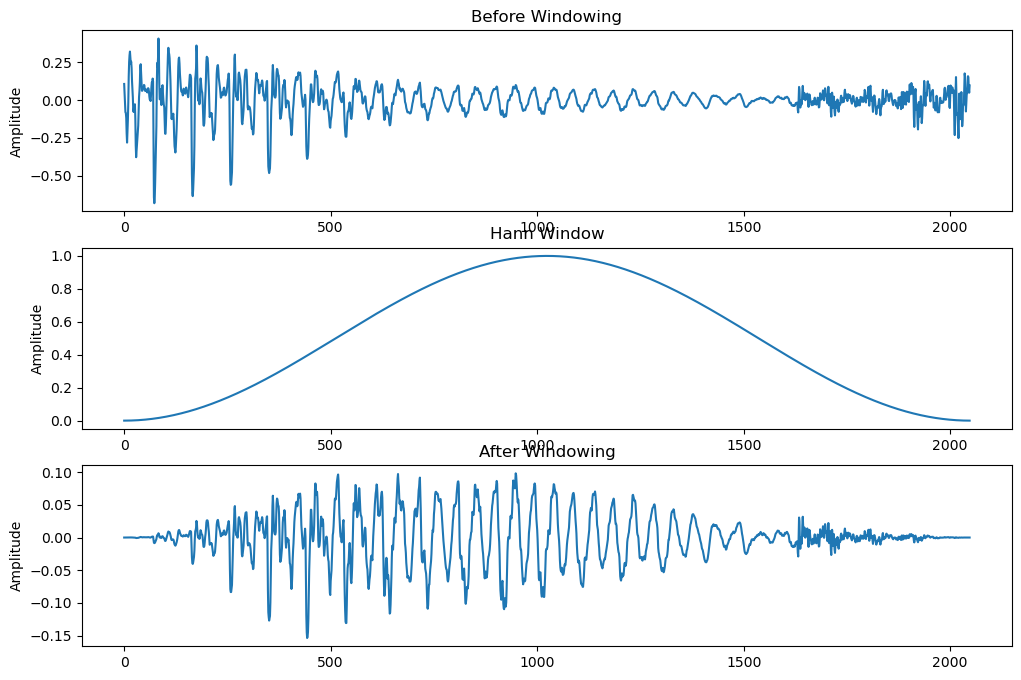

In [ ]:
frame_idx = 110

frame_before = audio_framed[frame_idx]
frame_after = audio_win[frame_idx]

# match axis x sesuai sama panjang frame
samples = np.arange(len(frame_before))

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Before Windowing
axes[0].plot(samples, frame_before)
axes[0].set_title("Before Windowing")
axes[0].set_ylabel("Amplitude")

# Hann Window
axes[1].plot(samples, window)
axes[1].set_title("Hann Window")
axes[1].set_ylabel("Amplitude")

# After Windowing
axes[2].plot(samples, frame_after)
axes[2].set_title("After Windowing")
axes[2].set_ylabel("Amplitude")

In [ ]:
# FFT: convert time domain ke frequency domain

# input audio bernilai dari bilangan rill, jadi FFT simetris
audio_fft = np.empty((int(1 + FFT_size // 2), audio_winT.shape[1]), dtype=np.complex64, order='F') # inisialisasi array kosong untuk simpan hasil FFT

for i in range(audio_fft.shape[1]):
    audio_fft[:, i] = fft.fft(audio_winT[:, i], axis=0)[:audio_fft.shape[0]]
    
audio_fft = np.transpose(audio_fft)  # transpose supaya bisa di plot
audio_fft.shape  # (frame_num, FFT_size/2+1)

print(audio_fft[:3, :5])  # print 3 frame pertama, 5 frekuensi pertama

[[ 0.0000000e+00-0.0000000e+00j  0.0000000e+00+0.0000000e+00j
   0.0000000e+00-0.0000000e+00j  0.0000000e+00+0.0000000e+00j
   0.0000000e+00+0.0000000e+00j]
 [-2.6664366e-05-0.0000000e+00j -3.2461361e-05+4.5014335e-06j
  -4.5709254e-05-8.0670873e-07j -5.6174998e-05-2.0024787e-05j
  -5.3024898e-05-4.8752572e-05j]
 [-1.1375252e-03-0.0000000e+00j -7.9884951e-04-7.9587800e-04j
   3.0647814e-05-1.0903946e-03j  7.9461973e-04-6.3020957e-04j
   8.6146430e-04+2.4617129e-04j]]


In [ ]:
# Audio Power: spektrum daya audio
# Menghitung kuadrat dari amplitudo FFT

# Habis FFT, outputnya bilangan complex, jadi kita ambil magnitudo lalu dikuadrat

audio_powert = np.square(np.abs(audio_fft))

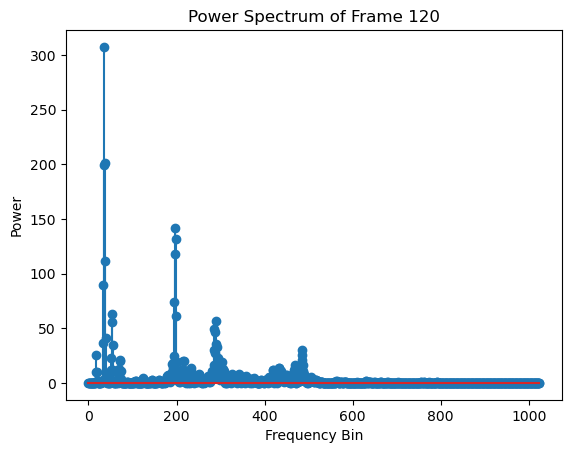

In [ ]:
frame = 120

plt.stem(audio_powert[frame])

plt.xlabel("Frequency Bin")
plt.ylabel("Power")
plt.title(f"Power Spectrum of Frame {frame}")
plt.show()